In [25]:
import os
import subprocess
import chemiscope
import ipi
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
import nqetools as nqe
from ase.visualize import view
# This follows:
# https://atomistic-cookbook.org/examples/pi-metad/pi-metad.html

In [2]:
# Make a directory to store everything
directory_md = "md"
directory_metamd = "metamd"
directory_metapimd = "metapimd"
n_beads = 8
timestep = 1.0
total_steps = 5000
stride = 10
temperature = 298

In [3]:
atoms = read("h5o2+.xyz", index=-1)
atoms.center(vacuum=20.0)
view(atoms)

<Popen: returncode: None args: ['/home/louie/anaconda3/envs/ipi_env2/bin/pyt...>

In [ ]:
# Run unbiased MD
# Make sure the directory is empty
nqe.remove_directory(directory_md)
# Run the calculation
nqe.run_md(directory_md, atoms,
           driver='zundel',
           md_type="NVT-GLE",
           # xml_in="input-md.xml",
           n_beads=1,
           timestep=timestep,
           total_steps=total_steps,
           stride=stride,
           temperature=temperature,
           )

In [ ]:
view(atoms)

In [4]:
# Run metadynamics
# Make sure the directory is empty
nqe.remove_directory(directory_metamd)
# Run the calculation
atoms = nqe.run_plumed_md(directory_metamd, atoms,
                          driver='zundel',
                          md_type="NVT-GLE",
                          n_beads=1,
                          timestep=timestep,
                          total_steps=total_steps,
                          stride=stride,
                          temperature=temperature,
                          plumed_type="mtd-coord",
                          )

The directory metamd does not exist.
Running plumed MD (NVT-GLE) with the driver: /home/louie/anaconda3/envs/ipi_env2/lib/python3.12/site-packages/ipi/bin/i-pi-driver -u -a zundel -m zundel


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/louie/plumed-2.9.3/src/lib/libplumedKernel.so" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.9.3 (git: Unknown) compiled on Jan 23 2025 at 11:26:41
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/louie/plumed-2.9.3/
PLUMED: For installed feature, see /home/louie/plumed-2.9.3//src/config/config.txt
PLUMED: Molecular dynamics engine: i-pi
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 7
PLUMED: File suffix: 
PLUMED: FILE: plumed.dat
PLUMED: Action DISTANCE
PLUMED:   with label d
PLUMED:   between atoms 1 2
PLUMED:   using periodic boundary conditions
PLUMED: Action DISTANCES
PLUMED:   with label c1
PLUMED:   keyword GROUPA takes atoms : 1 
PLUMED:   keyword GROUPB takes atoms : 3 4 5 6 7 
PLUMED:   added component to this action:  c1.lessthan 
PLUMED:   value c1.lessthan is obtained by taking the 1th component and finding the number

In [7]:
output_data, output_desc = ipi.read_output(os.path.join(directory_metamd, "md.out"))
colvar_data = ipi.read_trajectory(os.path.join(directory_metamd,"md.colvar_0"), format="extras")[
    "d,c1.lessthan,c2.lessthan,dc,mtd.bias"
]
traj_data = ipi.read_trajectory(os.path.join(directory_metamd, "md.pos_0.xyz"))

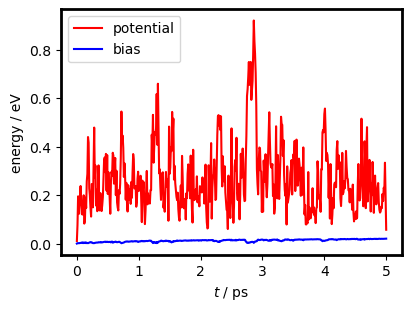

In [10]:
nqe.plot_time_potential_bias(output_data)

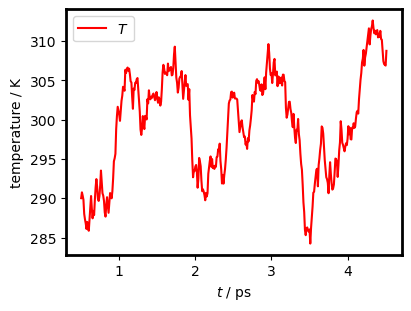

In [23]:
nqe.plot_time_temperature(output_data)

In [26]:

sum_hills_str= f"plumed sum_hills --hills HILLS-md --min 0.21,-1 --max 0.31,1 --bin 100,100 --outfile FES-md --stride 100 --mintozero < {os.path.join(directory_metamd,"plumed.dat")}"


with open(os.path.join(directory_metamd,"plumed.dat"), "r") as file:
    subprocess.run(sum_hills_str.split(), stdin=file,text=True,
    )



Usage: sum_hills < inputFile 
inputFile should contain one directive per line.  The directives should come from amongst the following


The following options are available

              --help/-h - ( default=off ) print this help 
           --help-debug - ( default=off ) print special options that can be used to 
                          create regtests 
              --negbias - ( default=off ) print the negative bias instead of the free 
                          energy (only needed with well tempered runs and flexible hills) 
            --nohistory - ( default=off ) to be used with --stride: it splits the 
                          bias/histogram in pieces without previous history 
            --mintozero - ( default=off ) it translate all the minimum value in 
                          bias/histogram to zero (useful to compare results) 
                --hills - specify the name of the hills file 
                --histo - specify the name of the file for histogram a colvar/hil

ERROR in input for command line tool sum_hills : < option is unknown 

